In [1]:
import numpy as np
from numpy import ndarray, sin, cos
from scipy.stats import multivariate_normal
from scipy.ndimage import convolve
import cv2
import matplotlib.pyplot as plt

In [2]:

class AbstractFilter:
    def set_attribute(self, **kwargs) -> None:
        pass

    def apply(self, image: list[ndarray] | ndarray) -> ndarray:
        pass


噪声过滤器：有按点添加噪声或者全局正态扰动噪声两种模式

In [3]:
class NoiseFilter(AbstractFilter):
    def __init__(self, factor: float = 0, noise_point: bool = False):
        self.factor = factor
        self.mode = noise_point

    def set_attribute(self, **kwargs) -> None:
        if kwargs is None:
            return
        factor = kwargs.get('factor', self.factor)
        if isinstance(factor, float) or isinstance(factor, int):
            if factor > 1 or factor < 0:
                raise ValueError('parameter \'factor\' must be between 0 and 1, but it is ' + factor + '.')
            self.factor = factor
        else:
            raise TypeError('parameter \'factor\' must be float, but it is ' + type(factor).__name__ + '.')
        noise_point = kwargs.get('noise_point', self.mode)
        if not isinstance(noise_point, bool):
            raise TypeError('parameter \'noise_point\' must be bool, but it is ' + type(noise_point).__name__ + '.')
        self.mode = noise_point

    def apply(self, image: list[ndarray] | ndarray) -> ndarray:
        if not isinstance(image, ndarray):
            raise TypeError('parameter \'image\' must be ndarray, but it is ' + type(image).__name__ + '.')
        if len(image.shape) != 3 and len(image.shape) != 2:
            raise ValueError('parameter \'image\' must be a 2d or 3d ndarray, but it has ' + str(len(image.shape)) + ' dimensions.')
        if self.mode:
            return self._apply_point(image)
        else:
            return self._apply_normal(image)

    def _apply_normal(self, image: ndarray) -> ndarray:
        res = image + np.random.normal(0, 255 * self.factor, size=image.shape)
        return (np.floor(np.clip(res, 0, 255))).astype(np.uint8)
    
    def _apply_point(self, image: ndarray) -> ndarray:
        res = np.copy(image)
        if len(res.shape) == 3:
            mask: ndarray = np.random.rand(*image.shape[:-1]) < self.factor
            for channel in range(max(3, res.shape[2])): 
                res[:, :, channel][mask] = (np.floor(np.random.rand(np.sum(mask)) * 256)).astype(np.uint8)
        else:
            mask: ndarray = np.random.rand(*image.shape) < self.factor
            res[mask] = (np.floor(np.random.rand(np.sum(mask)) * 256)).astype(np.uint8)
        return res
        

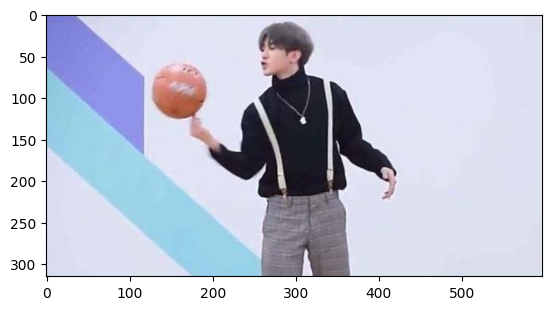

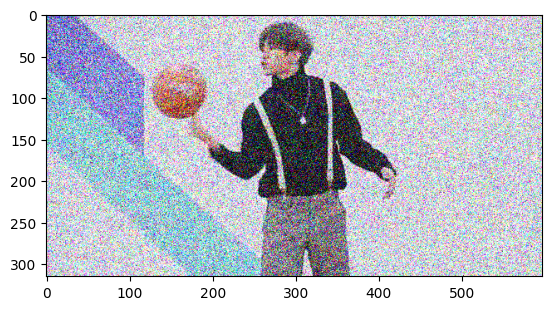

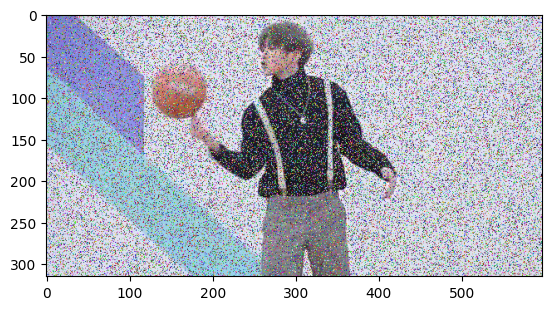

In [16]:
image = cv2.imread('./R-C.bmp')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
filter_noise = NoiseFilter(0.3, False)
out_image = filter_noise.apply(image)
plt.imshow(image)
plt.show()
plt.imshow(out_image)
plt.show()
filter_noise.set_attribute(noise_point=True)
out_image = filter_noise.apply(image)
plt.imshow(out_image)
plt.show()

定向模糊过滤器：雨雾效果内部需要竖直模糊，有高斯模糊和均值模糊两种模式

In [5]:
class BlurFilter(AbstractFilter):
    def __init__(self, factor: float = 0, mode: str = 'gauss', polarity: float = 0, axis_angle: float = 0):
        self.factor = factor
        if mode == 'gauss':
            self.mode = 0
        elif mode == 'average':
            self.mode = 1
        else:
            raise ValueError('parameter \'mode\' must be \'gauss\' or \'average\', but it is \'' + mode + '\'.')
        
        self.polarity = polarity
        self.axis_angle = axis_angle
        

    def set_attribute(self, **kwargs) -> None:
        if kwargs is None:
            return
        factor = kwargs.get('factor', self.factor)
        if isinstance(factor, float) or isinstance(factor, int):
            if factor > 1 or factor < 0:
                raise ValueError('parameter \'factor\' must be between 0 and 1, but it is ' + factor + '.')
            self.factor = factor
        else:
            raise TypeError('parameter \'factor\' must be float, but it is ' + type(factor).__name__ + '.')
        mode = kwargs.get('mode', None)
        if mode is None:
            return
        if not isinstance(mode, str):
            raise TypeError('parameter \'mode\' must be str, but it is ' + type(mode).__name__ + '.')
        if mode == 'gauss':
            self.mode = 0
        elif mode == 'average':
            self.mode = 1
        else:
            raise ValueError('parameter \'mode\' must be \'gauss\' or \'average\', but it is \'' + mode + '\'.')


    def apply(self, image: list[ndarray] | ndarray) -> ndarray:
        if not isinstance(image, ndarray):
            raise TypeError('parameter \'image\' must be ndarray, but it is ' + type(image).__name__ + '.')
        if len(image.shape) != 3 and len(image.shape) != 2:
            raise ValueError('parameter \'image\' must be a 2d or 3d ndarray, but it has ' + str(len(image.shape)) + ' dimensions.')
        if self.mode == 0:
            return self._apply_gauss(image)
        else:
            return self._apply_average(image)
    
    def _apply_gauss(self, image: ndarray) -> ndarray:
        size = max(int(np.floor(min(image.shape[:2]) * self.factor*0.2)), 1)
        if (size == 1):
            return np.copy(image)
        polarity = np.clip(self.polarity, 0, 1-1e-4)
        cov = np.array([[(1+polarity)/2, 0], [0, (1-polarity)/2]])
        rotate_M = np.array([[cos(self.axis_angle), sin(self.axis_angle)], [-sin(self.axis_angle), cos(self.axis_angle)]])
        cov = rotate_M @ cov @ rotate_M.T
        center = (size - 1) / 2
        cov *= center * center / 2.25
        x, y = np.meshgrid(np.linspace(-center, center, size), np.linspace(-center, center, size))
        kernel = multivariate_normal.pdf(np.dstack((x, y)), mean=(0, 0), cov=cov)
        kernel /= np.nansum(kernel)
        if len(image.shape) == 2:
            return convolve(image, kernel, mode='nearest')
        res = np.zeros_like(image)
        for channel in range(res.shape[2]):
            res[:, :, channel] = convolve(image[:, :, channel], kernel, mode='nearest')
        return res
    
    def _apply_average(self, image: ndarray) -> ndarray:
        size = max(int(np.floor(min(image.shape[:2]) * self.factor*0.15)), 1)
        width = max((1.0 - self.polarity) * size, 1)
        if (size == 1):
            return np.copy(image)
        center = (size - 1) / 2
        x, y = np.meshgrid(np.arange(size), np.arange(size))
        line_distance = np.abs((x - center) * -np.sin(self.axis_angle) - (y - center) * np.cos(self.axis_angle))
        kernel = np.zeros((size, size))
        kernel[line_distance <= width / 2] = 1
        kernel /= np.nansum(kernel)
        if len(image.shape) == 2:
            return convolve(image, kernel, mode='nearest')
        res = np.zeros_like(image)
        for channel in range(res.shape[2]):
            res[:, :, channel] = convolve(image[:, :, channel], kernel, mode='nearest')
        return res



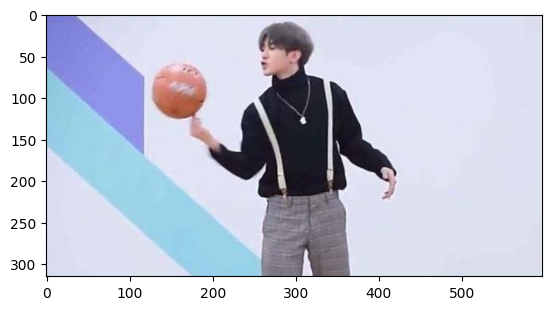

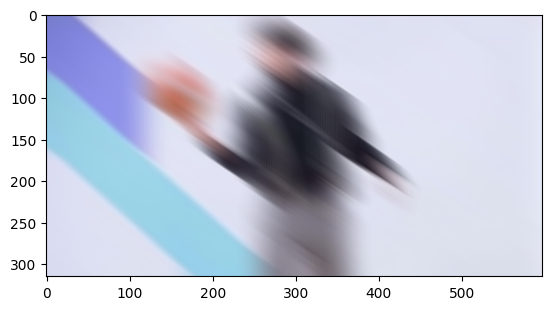

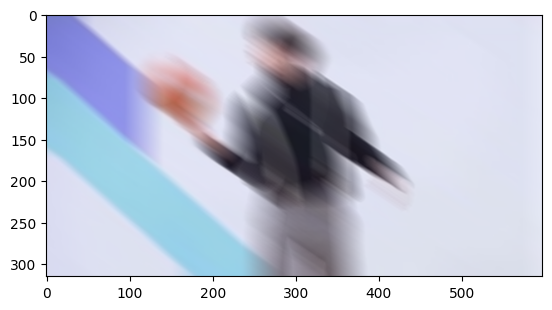

In [6]:
image = cv2.imread('./R-C.bmp')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
filter_noise = BlurFilter(1, polarity=1, axis_angle=np.pi*6.5/8)
out_image = filter_noise.apply(image)
plt.imshow(image)
plt.show()
plt.imshow(out_image)
plt.show()
filter_noise.set_attribute(mode='average')
out_image = filter_noise.apply(image)
plt.imshow(out_image)
plt.show()

雨雾效果过滤器：以factor为程度添加雨滴线并进行竖直模糊

In [9]:
class RainningFilter(AbstractFilter):
    def __init__(self, factor: float):
        self.factor = factor
        self.blur = BlurFilter(0.225 * factor, polarity=0.8, axis_angle=np.pi/2)

    def set_attribute(self, **kwargs) -> None:
        self.factor = kwargs['factor']
        self.blur.set_attribute(kwargs)

    def apply(self, image: ndarray) -> ndarray:
        rain = np.zeros_like(image, dtype=np.uint8)
        num_drops = int(np.round(0.003 * image.shape[0] * image.shape[1] * self.factor))
        rain_len = int(np.round(image.shape[1] * 0.1))
        for _ in range(num_drops):
            x, y = np.random.randint(0, image.shape[1]), np.random.randint(0, image.shape[0])
            cv2.line(rain, (x, y-rain_len), (x, y + rain_len), (255, 255, 255), 1)
        rain = cv2.GaussianBlur(rain, (5, 5), 0)
        rain_alpha = 0.6 * self.factor
        image_with_rain = cv2.addWeighted(image, 1, rain, rain_alpha, 0)
        return self.blur.apply(image_with_rain)

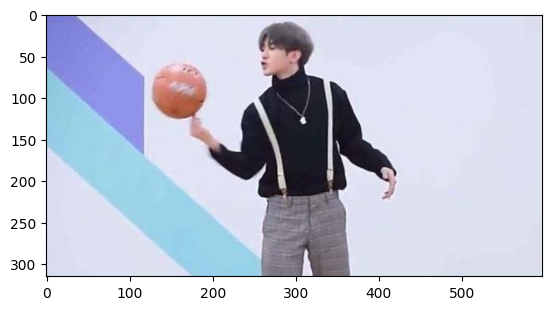

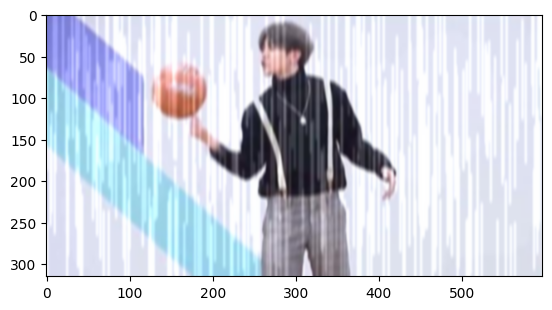

In [15]:

image = cv2.imread('./R-C.bmp')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

filter = RainningFilter(0.65)
image_with_fog = filter.apply(image)
plt.imshow(image)
plt.show()
plt.imshow(image_with_fog)
plt.show()
